# 3.6 Calibration du modèle

# Q1

In [14]:
import numpy as np
from scipy.stats import norm

t       = 0.0
delta   = 1.0
lambda_ = 0.05
N       = 1.0
Ti      = 6.0
Ti_fix  = Ti - delta

B_Ti     = 0.830609 # valeur reprise sur la courbe zero
B_Ti_fix = 0.863028

L_fwd = (1/delta) * (B_Ti_fix / B_Ti - 1)
K     = L_fwd

price_market = 0.007137

print(f"L_ATM           = {L_fwd:.4%}")
print(f"Prix marché ATM = {price_market:.4%}")

def black_caplet_HW(sigma_i, L, K, delta, B_Ti, Ti, t, N=1):
    Z_t     = 1 + delta * L
    K_tilde = 1 + delta * K
    Ti_fix  = Ti - delta
    sqrtT   = np.sqrt(Ti_fix - t)
    d1 = (np.log(Z_t / K_tilde) + 0.5 * sigma_i**2 * (Ti_fix - t)) / (sigma_i * sqrtT)
    d2 = sigma_i * sqrtT - d1
    return N * delta * B_Ti * (Z_t * norm.cdf(d1) - K_tilde * norm.cdf(-d2))

def dichotomie(price_cible, L, K, delta, B_Ti, Ti, t, N=1,
               tol=1e-6, s_low=1e-4, s_high=1.0):
    f_low  = black_caplet_HW(s_low,  L, K, delta, B_Ti, Ti, t, N)
    f_high = black_caplet_HW(s_high, L, K, delta, B_Ti, Ti, t, N)
    if f_low  > price_cible: return s_low
    if f_high < price_cible: return s_high
    while s_high - s_low > tol:
        s_mid = (s_low + s_high) / 2
        f_low = black_caplet_HW(s_low, L, K, delta, B_Ti, Ti, t, N)
        f_mid = black_caplet_HW(s_mid, L, K, delta, B_Ti, Ti, t, N)
        if (f_low - price_cible) * (f_mid - price_cible) > 0:
            s_low = s_mid
        else:
            s_high = s_mid
    return (s_low + s_high) / 2

sigma_i = dichotomie(price_market, L_fwd, K, delta, B_Ti, Ti, t, N)
print(f"Volatilité implicite   = {sigma_i*100:.4f} %")

beta_sq   = ((1 - np.exp(-lambda_ * delta)) / lambda_)**2
phi_coeff = (1 - np.exp(-2 * lambda_ * Ti_fix)) / (2 * lambda_)
sigma     = np.sqrt(sigma_i**2 * Ti_fix / (beta_sq * phi_coeff))

print(f"Volatilité instantanée = {sigma*100:.4f} %")

L_ATM           = 3.9030%
Prix marché ATM = 0.7137%
Volatilité implicite   = 0.9270 %
Volatilité instantanée = 1.0713 %


# Q2

In [16]:
# Strikes en bps
strikes_bps = [-100, -50, -25, 0, 25, 50, 100]

print(f"{'Strike (bps)':<15} {'Strike (%)':<15} {'Prix modèle HW':<15}")
print("-" * 45)

for s_bps in strikes_bps:
    K_s = L_fwd + s_bps / 10000
    price_HW = black_caplet_HW(sigma_i, L_fwd, K_s, delta, B_Ti, Ti, t, N)
    print(f"{s_bps:<15} {K_s:.4%}        {price_HW:.4%}")

Strike (bps)    Strike (%)      Prix modèle HW 
---------------------------------------------
-100            2.9030%        1.2015%
-50             3.4030%        0.9388%
-25             3.6530%        0.8214%
0               3.9030%        0.7137%
25              4.1530%        0.6155%
50              4.4030%        0.5268%
100             4.9030%        0.3770%


Q3


--- COMPARAISON DES SMILES DE VOLATILITÉ ---
Strike (bps)    Prix HW         Vol. Impl. HW   Vol. Impl. Marché
-----------------------------------------------------------------
-100            1.2015%       28.87%           31.20%
-50             0.9388%       26.74%           28.40%
-25             0.8214%       25.83%           26.60%
0               0.7137%       25.00%           25.00%
25              0.6155%       24.24%           24.40%
50              0.5268%       23.55%           25.00%
100             0.3770%       22.30%           27.20%


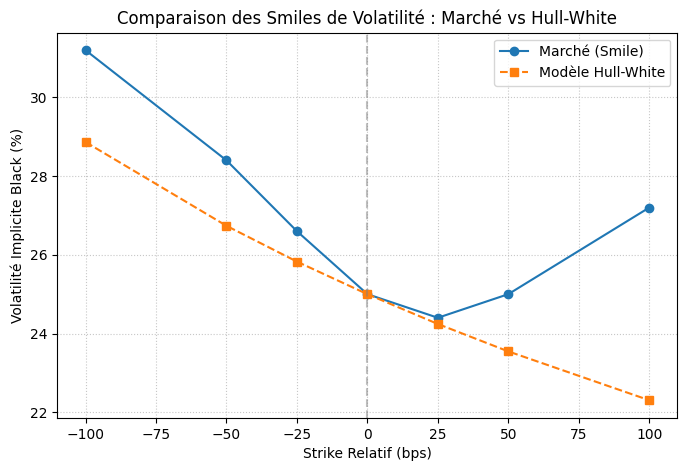

In [8]:
import matplotlib.pyplot as plt

# 1. Fonction de valorisation Black Standard (celle du marché, Partie 2)
def black_caplet_standard(sigma_blk, L, K, delta, B_Ti, Ti_fix, N=1):
    sqrtT = np.sqrt(Ti_fix)
    d1 = (np.log(L / K) + 0.5 * sigma_blk**2 * Ti_fix) / (sigma_blk * sqrtT)
    d2 = d1 - sigma_blk * sqrtT
    return N * delta * B_Ti * (L * norm.cdf(d1) - K * norm.cdf(d2))

# 2. Inversion de la fonction Black Standard par dichotomie
def implied_vol_standard(price_cible, L, K, delta, B_Ti, Ti_fix, N=1, tol=1e-6):
    s_low, s_high = 1e-4, 2.0
    for _ in range(100):
        s_mid = (s_low + s_high) / 2
        f_mid = black_caplet_standard(s_mid, L, K, delta, B_Ti, Ti_fix, N)
        if f_mid > price_cible:
            s_high = s_mid
        else:
            s_low = s_mid
        if s_high - s_low < tol:
            break
    return s_mid

# 3. Données de marché (Volatilités implicites issues du Tableau 1 / Section 2)
market_vols = [0.312, 0.284, 0.266, 0.250, 0.244, 0.250, 0.272]

# 4. Calcul des volatilités implicites du modèle Hull-White
hw_implied_vols = []

print("\n--- COMPARAISON DES SMILES DE VOLATILITÉ ---")
print(f"{'Strike (bps)':<15} {'Prix HW':<15} {'Vol. Impl. HW':<15} {'Vol. Impl. Marché':<15}")
print("-" * 65)

for s_bps, vol_mkt in zip(strikes_bps, market_vols):
    K_s = L_fwd + s_bps / 10000
    # On récupère le prix HW (déjà calculé à la Q2)
    price_HW = black_caplet_HW(sigma_i, L_fwd, K_s, delta, B_Ti, Ti, t, N)

    # On inverse ce prix dans le modèle de Black Standard
    vol_HW = implied_vol_standard(price_HW, L_fwd, K_s, delta, B_Ti, Ti_fix, N)
    hw_implied_vols.append(vol_HW)

    print(f"{s_bps:<15} {price_HW:.4%}       {vol_HW*100:.2f}%           {vol_mkt*100:.2f}%")

# 5. Tracé du graphique (Smile de volatilité)
plt.figure(figsize=(8, 5))
plt.plot(strikes_bps, [v * 100 for v in market_vols], marker='o', label='Marché (Smile)')
plt.plot(strikes_bps, [v * 100 for v in hw_implied_vols], marker='s', linestyle='--', label='Modèle Hull-White')

plt.title("Comparaison des Smiles de Volatilité : Marché vs Hull-White")
plt.xlabel("Strike Relatif (bps)")
plt.ylabel("Volatilité Implicite Black (%)")
plt.legend()
plt.grid(True, linestyle=':', alpha=0.7)
plt.axvline(x=0, color='gray', linestyle='--', alpha=0.5, label='ATM')
plt.show()

# part 3.7


# Q1

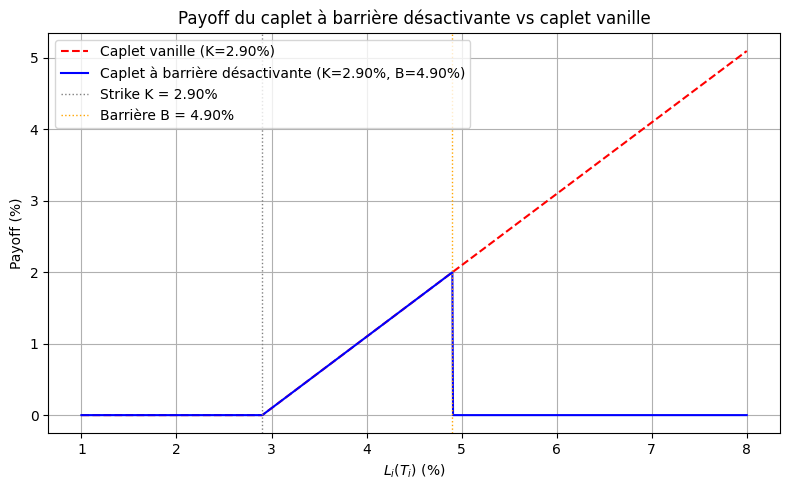

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

L_vals = np.linspace(0.01, 0.08, 1000)
K_bar  = L_fwd - 0.01
B_bar  = L_fwd + 0.01

payoff_vanilla  = np.maximum(L_vals - K_bar, 0)
payoff_barriere = np.maximum(L_vals - K_bar, 0) * (L_vals < B_bar)

plt.figure(figsize=(8, 5))
plt.plot(L_vals*100, payoff_vanilla*100,  'r--', label=f'Caplet vanille (K={K_bar:.2%})')
plt.plot(L_vals*100, payoff_barriere*100, 'b-',  label=f'Caplet à barrière désactivante (K={K_bar:.2%}, B={B_bar:.2%})')
plt.axvline(K_bar*100,   color='gray',   linestyle=':', linewidth=1, label=f'Strike K = {K_bar:.2%}')
plt.axvline(B_bar*100,   color='orange', linestyle=':', linewidth=1, label=f'Barrière B = {B_bar:.2%}')
plt.xlabel('$L_i(T_i)$ (%)')
plt.ylabel('Payoff (%)')
plt.title('Payoff du caplet à barrière désactivante vs caplet vanille')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# Q 3.7.5

In [ ]:
from scipy.integrate import quad
import numpy as np


def phi(t, sigma, lambda_):
    return (sigma**2 / (2 * lambda_)) * (1 - np.exp(-2 * lambda_ * t))

def beta_hw(t, T, lambda_):
    return (1 - np.exp(-lambda_ * (T - t))) / lambda_

def gamma_hw(t, T, sigma, lambda_):
    return (sigma / lambda_) * (np.exp(-lambda_ * (T - t)) - 1)

def B_hw(t, T, B0_T, B0_t, X_t, sigma, lambda_):
    b  = beta_hw(t, T, lambda_)
    ph = phi(t, sigma, lambda_)
    return (B0_T / B0_t) * np.exp(-0.5 * b**2 * ph - b * X_t)

# Paramètres
Ti_1 = 5
Ti   = 6
T_num = Ti  # numéraire pour QT
K_bar = L_fwd - 0.01   # ATM - 100 bps
B_bar = L_fwd + 0.01   # ATM + 100 bps
B0_5  = B_Ti_fix
B0_6  = B_Ti

# Moyenne conditionnelle E[X_5 | X_0=0] sous Q^{T=5}
def integrand_mean(u, sigma, lambda_, T):
    return np.exp(-lambda_ * (Ti_1 - u)) * (phi(u, sigma, lambda_)
                                           + sigma * gamma_hw(u, T, sigma, lambda_))

mu_X, _  = quad(integrand_mean, 0, Ti_1, args=(sigma, lambda_, T_num))
var_X    = (sigma**2) * (1 - np.exp(-2 * lambda_ * Ti_1)) / (2 * lambda_)
sigma_X  = np.sqrt(var_X)

print(f"Moyenne X_5|X_0 : {mu_X:.6f}")
print(f"Variance X_5|X_0 : {var_X:.6f}")

# Monte Carlo
N_sim  = 100000
np.random.seed(423)

X_sim  = np.random.normal(mu_X, sigma_X, N_sim)

B_5_6  = B_hw(5, 6, B0_6, B0_5, X_sim, sigma, lambda_)
B_5_5  = np.ones(N_sim)

L_sim  = (B_5_5 / B_5_6) - 1

payoffs = np.maximum(L_sim - K_bar, 0) * (L_sim < B_bar)

price   = B0_6 * np.mean(payoffs)
SE      = B0_6 * np.std(payoffs) / np.sqrt(N_sim)

print(f"\nPrix Monte-Carlo : {price:.6f}  ({price*100:.4f}%)")
print(f"Standard Error   : {SE:.6f}  ({SE*100:.4f}%)")

Moyenne X_5|X_0 : -0.000441
Variance X_5|X_0 : 0.000452

Prix Monte-Carlo : 0.002964  (0.2964%)
Standard Error   : 0.000015  (0.0015%)


# Q3.7.6

In [ ]:
# Barrière -> +inf avec strike ATM
payoffs_inf  = np.maximum(L_sim - L_fwd, 0)  # strike = ATM
price_inf    = B0_6 * np.mean(payoffs_inf)
SE_inf       = B0_6 * np.std(payoffs_inf) / np.sqrt(N_sim)

# Barrière -> 0 avec strike ATM
payoffs_zero = np.maximum(L_sim - L_fwd, 0) * (L_sim < 0)
price_zero   = B0_6 * np.mean(payoffs_zero)
SE_zero      = B0_6 * np.std(payoffs_zero) / np.sqrt(N_sim)

print(f"Barrière -> +inf : prix = {price_inf*100:.4f}%  SE = {SE_inf*100:.4f}%")
print(f"Barrière -> 0    : prix = {price_zero*100:.4f}%  SE = {SE_zero*100:.4f}%")
print(f"\nRappel prix caplet ATM marché : {price_market*100:.4f}%")

Barrière -> +inf : prix = 0.7154%  SE = 0.0033%
Barrière -> 0    : prix = 0.0000%  SE = 0.0000%

Rappel prix caplet ATM marché : 0.7137%


# Q 3.7.7

In [38]:
N_sim  = 100000
Ti_1   = 5
Ti     = 6
K_bar  = L_fwd - 0.01
B_bar  = L_fwd + 0.01
dates  = [1, 2, 3, 4, 5]

payoffs = np.zeros(N_sim)
np.random.seed(423)

for sim in range(N_sim):
    X      = {0: 0.0}
    active = True

    for t in dates:
        s   = t - 1
        mu_X, _ = quad(lambda u, t=t: np.exp(-lambda_*(t-u)) * (
                        phi(u, sigma, lambda_) +
                        sigma * gamma_hw(u, Ti_1, sigma, lambda_)),
                        s, t)
        sigma_X = np.sqrt(compute_variance(sigma, lambda_, t, s))
        X[t]    = np.random.normal(mu_X, sigma_X)

        # Taux euribor 12M forward vu de t : fixe en 5, paie en 6
        B_t_5 = B_hw(t, 5, get_B0(5), get_B0(t), X[t], sigma, lambda_)
        B_t_6 = B_hw(t, 6, get_B0(6), get_B0(t), X[t], sigma, lambda_)
        L_t   = (B_t_5 / B_t_6) - 1

        if L_t >= B_bar:
            active = False
            break

    if active:
        B_5_6        = B_hw(5, 6, get_B0(6), get_B0(5), X[5], sigma, lambda_)
        L_final      = (1 / B_5_6) - 1
        payoffs[sim] = np.maximum(L_final - K_bar, 0)
    else:
        payoffs[sim] = 0.0

price_berm = get_B0(6) * np.mean(payoffs)
SE_berm    = get_B0(6) * np.std(payoffs) / np.sqrt(N_sim)

print(f"Prix barrière bermudéenne : {price_berm*100:.4f}%  SE = {SE_berm*100:.4f}%")
print(f"Rappel prix barrière européenne (Q5) : 0.2967%")

Prix barrière bermudéenne : 0.2810%  SE = 0.0015%
Rappel prix barrière européenne (Q5) : 0.2967%


# Q3.7.8

In [ ]:
# ==========================================
# QUESTION 3.7.8 : SENSIBILITÉ À LAMBDA
# ==========================================

lambdas_test = [0.01, 0.03, 0.05, 0.10, 0.15, 0.20]
N_sim = 100000
np.random.seed(423) # On garde la même graine pour comparer les prix de façon stable

print("--- Sensibilité au paramètre de mean-reversion (lambda) ---")
print(f"{'Lambda':<10} {'Sigma Calibré':<15} {'Prix Barrière':<15} {'SE':<10}")
print("-" * 55)

for l in lambdas_test:
    # 1. Recalibration de sigma pour le lambda donné
    # La volatilité implicite de Black (sigma_i = 0.9270%) reste la même car le prix cible ATM (0.7137%) ne change pas.
    beta_sq = ((1 - np.exp(-l * delta)) / l)**2
    phi_coeff = (1 - np.exp(-2 * l * Ti_1)) / (2 * l)
    s_calib = np.sqrt(sigma_i**2 * Ti_1 / (beta_sq * phi_coeff))

    # 2. Paramètres de la distribution de X_5 sous Q^6
    mu_X, _ = quad(integrand_mean, 0, Ti_1, args=(s_calib, l, Ti))
    var_X = (s_calib**2) * (1 - np.exp(-2 * l * Ti_1)) / (2 * l)
    sigma_X = np.sqrt(var_X)

    # 3. Monte Carlo (Barrière Européenne)
    X_sim = np.random.normal(mu_X, sigma_X, N_sim)

    # Rappel : B_5_5 = 1.0 (zéro-coupon à maturité)
    B_5_6 = B_hw(5, 6, B0_6, B0_5, X_sim, s_calib, l)
    L_sim = (1 / B_5_6) - 1

    # Payoff de la barrière européenne
    payoffs = np.maximum(L_sim - K_bar, 0) * (L_sim < B_bar)
    price = B0_6 * np.mean(payoffs)
    SE = B0_6 * np.std(payoffs) / np.sqrt(N_sim)

    print(f"{l*100:>5.1f}%     {s_calib*100:>10.4f}%       {price*100:>10.4f}%      {SE*100:>7.4f}%")

--- Sensibilité au paramètre de mean-reversion (lambda) ---
Lambda     Sigma Calibré   Prix Barrière   SE        
-------------------------------------------------------
  1.0%         0.9550%           0.2964%       0.0015%
  3.0%         1.0124%           0.2969%       0.0015%
  5.0%         1.0713%           0.2959%       0.0015%
 10.0%         1.2252%           0.2945%       0.0015%
 15.0%         1.3871%           0.2942%       0.0015%
 20.0%         1.5555%           0.2966%       0.0015%
